# Classify raw dataset

This notebook is used to classify the raw not cleaned datasets (datikz-v4, our collected dataset). For the classification a clustering approach is selected. 

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset, concatenate_datasets
from transformers import AutoModel, AutoProcessor
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm


### 1. CONFIG

In [14]:
# Dataset paths
DATIKZ_DIR = Path("/home/jonas/Datasets/TikZ/DatikZ-v4")
BENCHMARK_DIR = Path("/home/jonas/Datasets/TikZ/benchmark-not-clean")

# Choose one or both datasets:
# ("datikz",)
# ("benchmark",)
# ("datikz", "benchmark")
DATASETS_TO_USE = ("datikz", "benchmark")

# Input schemas
DATIKZ_IMAGE_COL = "png_image"
DATIKZ_ID_COL = "file_id"
DATIKZ_SOURCE_COL = "source"

BENCHMARK_IMAGE_COL = "image"
BENCHMARK_ID_COL = "uri"
BENCHMARK_SOURCE_COL = "origin"

# None uses the complete dataset. Sampling is applied per dataset.
N_SAMPLES_DATIKZ = 10_000
N_SAMPLES_BENCHMARK = 10_000

N_CLUSTERS = 6
BATCH_SIZE = 128
SEED = 42

IMAGE_COL = "image"

# Choose "clip", "siglip" or "siglip2".
EMBEDDING_BACKBONE = "clip"

MODEL_IDS = {
    "clip": "openai/clip-vit-base-patch32",
    "siglip": "google/siglip-base-patch16-224",
    "siglip2": "google/siglip2-base-patch16-224",
}

if EMBEDDING_BACKBONE not in MODEL_IDS:
    raise ValueError(
        f"EMBEDDING_BACKBONE must be one of {sorted(MODEL_IDS)}, "
        f"got {EMBEDDING_BACKBONE!r}"
    )

MODEL_ID = MODEL_IDS[EMBEDDING_BACKBONE]
OUTPUT_PREFIX = f"{'_'.join(DATASETS_TO_USE)}_{EMBEDDING_BACKBONE}"


### 2. LOAD DATA

Each selected dataset is normalized to the same temporary schema. Set
`DATASETS_TO_USE` to `("datikz",)`, `("benchmark",)`, or
`("datikz", "benchmark")`. When both are enabled, their rows are concatenated
only for embedding and clustering. The `dataset` column preserves the origin
of every sample.


In [15]:
def load_local_dataset(path: Path):
    parquet_files = sorted(path.rglob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"No parquet files found in {path}")

    return load_dataset(
        "parquet",
        data_files=[str(file) for file in parquet_files],
        split="train",
    )


def normalize_dataset(
    dataset,
    dataset_name: str,
    image_col: str,
    id_col: str,
    source_col: str,
):
    required = {image_col, id_col, source_col}
    missing = required - set(dataset.column_names)
    if missing:
        raise ValueError(
            f"{dataset_name} is missing required columns: {sorted(missing)}"
        )

    if image_col != IMAGE_COL:
        dataset = dataset.rename_column(image_col, IMAGE_COL)

    has_caption = "caption" in dataset.column_names

    def add_metadata(row, index):
        raw_id = row[id_col]
        return {
            "dataset": dataset_name,
            "sample_id": f"{dataset_name}:{raw_id if raw_id is not None else index}",
            "source": row[source_col],
            "caption": row["caption"] if has_caption else "",
        }

    dataset = dataset.map(
        add_metadata,
        with_indices=True,
        desc=f"Normalize {dataset_name}",
    )

    return dataset.select_columns(
        [IMAGE_COL, "dataset", "sample_id", "source", "caption"]
    )


def sample_dataset(dataset, n_samples, seed):
    if n_samples is None:
        return dataset

    n = min(int(n_samples), len(dataset))
    return dataset.shuffle(seed=seed).select(range(n))


selected_datasets = set(DATASETS_TO_USE)
allowed_datasets = {"datikz", "benchmark"}

if not selected_datasets:
    raise ValueError("DATASETS_TO_USE must not be empty.")

unknown_datasets = selected_datasets - allowed_datasets
if unknown_datasets:
    raise ValueError(f"Unknown dataset names: {sorted(unknown_datasets)}")

datasets_to_cluster = []

if "datikz" in selected_datasets:
    datikz = normalize_dataset(
        load_local_dataset(DATIKZ_DIR),
        dataset_name="datikz",
        image_col=DATIKZ_IMAGE_COL,
        id_col=DATIKZ_ID_COL,
        source_col=DATIKZ_SOURCE_COL,
    )
    datikz = sample_dataset(datikz, N_SAMPLES_DATIKZ, SEED)
    datasets_to_cluster.append(datikz)

if "benchmark" in selected_datasets:
    benchmark = normalize_dataset(
        load_local_dataset(BENCHMARK_DIR),
        dataset_name="benchmark",
        image_col=BENCHMARK_IMAGE_COL,
        id_col=BENCHMARK_ID_COL,
        source_col=BENCHMARK_SOURCE_COL,
    )
    benchmark = sample_dataset(benchmark, N_SAMPLES_BENCHMARK, SEED + 1)
    datasets_to_cluster.append(benchmark)

sample = concatenate_datasets(datasets_to_cluster).shuffle(seed=SEED)

print(sample)
print(sample.column_names)
print(pd.Series(sample["dataset"]).value_counts())


Dataset({
    features: ['image', 'dataset', 'sample_id', 'source', 'caption'],
    num_rows: 20000
})
['image', 'dataset', 'sample_id', 'source', 'caption']
benchmark    10000
datikz       10000
Name: count, dtype: int64


Used images: 20,000


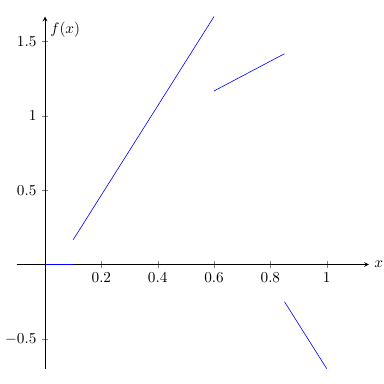

In [16]:
print(f"Used images: {len(sample):,}")
display(sample[0][IMAGE_COL])


### 3. CLIP-/SigLIP-/SigLIP2-IMAGE-EMBEDDINGS


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Embedding backbone:", EMBEDDING_BACKBONE)
print("Model:", MODEL_ID)

if EMBEDDING_BACKBONE == "siglip2":
    print("SigLIP2 requires a Transformers version with SigLIP2 support.")

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).eval().to(device)


Device: cuda
Embedding backbone: clip
Model: openai/clip-vit-base-patch32


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 74754.06it/s]


In [18]:
def encode_images(images) -> torch.Tensor:
    pixel_values = processor(
        images=images,
        return_tensors="pt",
    )["pixel_values"].to(device)

    with torch.inference_mode():
        output = model.vision_model(
            pixel_values=pixel_values,
            return_dict=True,
        )
        features = output.pooler_output

        if not isinstance(features, torch.Tensor):
            raise TypeError(
                f"Expected pooler_output tensor, got {type(features).__name__}"
            )

        projection = getattr(model, "visual_projection", None)
        if projection is not None:
            features = projection(features)

        if not isinstance(features, torch.Tensor):
            raise TypeError(
                f"Expected embedding tensor, got {type(features).__name__}"
            )

        return F.normalize(features.to(torch.float32), dim=-1)


all_embeddings = []

for start in tqdm(range(0, len(sample), BATCH_SIZE)):
    batch = sample[start : start + BATCH_SIZE]
    images = [image.convert("RGB") for image in batch[IMAGE_COL]]
    all_embeddings.append(encode_images(images).cpu().numpy())

embeddings = np.concatenate(all_embeddings, axis=0)
print("Embedding matrix:", embeddings.shape)

np.save(
    f"{OUTPUT_PREFIX}_embeddings.npy",
    embeddings,
)


100%|██████████| 157/157 [00:58<00:00,  2.68it/s]

Embedding matrix: (20000, 512)


### 4. PCA and Clustering

PCA and MiniBatchKMeans are fitted on the complete combined embedding matrix
when the benchmark dataset is enabled. Dataset membership does not influence
the clustering; it is retained only for analysis and later sampling.


### Clustering in High-Dimensional Spaces

Clustering methods can become less reliable in high-dimensional spaces. This is often referred to as the **curse of dimensionality**. As the number of dimensions increases, data becomes more sparse and distances between points become less informative.

Dimensionality reduction methods such as PCA can help by removing noise and redundant information, reducing computational cost, and making distance-based clustering more stable.


### Principal Component Analysis (PCA)

Principal Component Analysis reduces the dimensionality of the CLIP embeddings while preserving as much relevant variation as possible. For example, a 512-dimensional embedding can be reduced to 50 dimensions.

PCA is not strictly required, but it can make clustering faster, reduce memory usage, and remove noisy or redundant information. It is also useful for visualizing the embeddings in two dimensions.





In [19]:
n_components = min(10, embeddings.shape[0] - 1, embeddings.shape[1])

pca = PCA(n_components=n_components, random_state=SEED)
X = pca.fit_transform(embeddings)

clusterer = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=1024,
    n_init=10,
    random_state=SEED,
)
labels = clusterer.fit_predict(X)

print("PCA-Variance:", round(pca.explained_variance_ratio_.sum(), 3))


PCA-Variance: 0.465


### 5. Distribution of the clusters


dataset,benchmark,datikz,total,percent_total
cluster,,,,
0,1987,3168,5155,25.775
1,1669,1295,2964,14.820
2,2380,1663,4043,20.215
3,1319,1535,2854,14.270
4,1255,1301,2556,12.780
5,1390,1038,2428,12.140


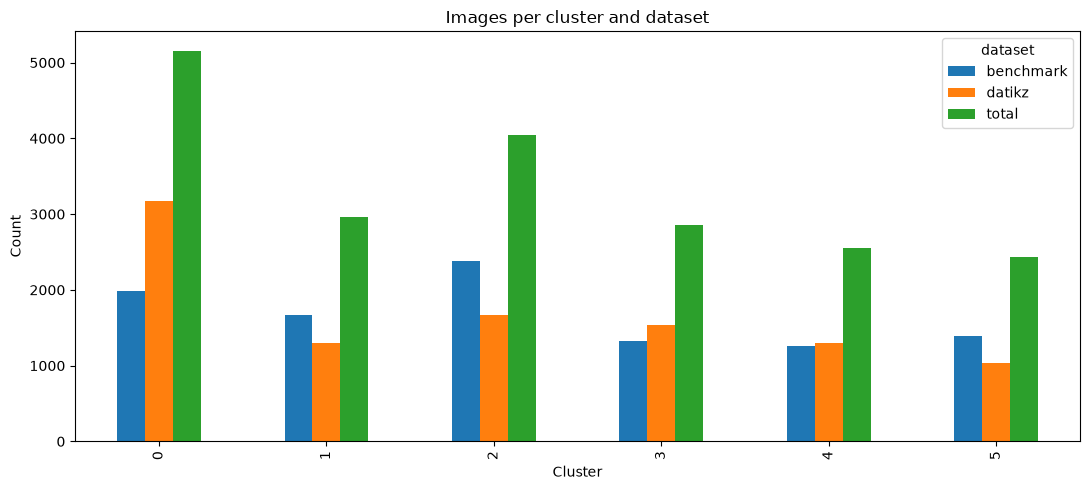

In [20]:
cluster_counts = (
    pd.DataFrame({
        "dataset": sample["dataset"],
        "cluster": labels,
    })
    .groupby(["cluster", "dataset"])
    .size()
    .unstack(fill_value=0)
)

cluster_counts["total"] = cluster_counts.sum(axis=1)
cluster_counts["percent_total"] = (
    100 * cluster_counts["total"] / len(labels)
)
display(cluster_counts)

cluster_counts.drop(columns="percent_total").plot.bar(
    figsize=(11, 5),
    title="Images per cluster and dataset",
    xlabel="Cluster",
    ylabel="Count",
)
plt.tight_layout()
plt.show()


### 6. Two-Dimensional Overview

This representation is only a rough projection. Overlapping points
do not necessarily mean that the clusters are poor.


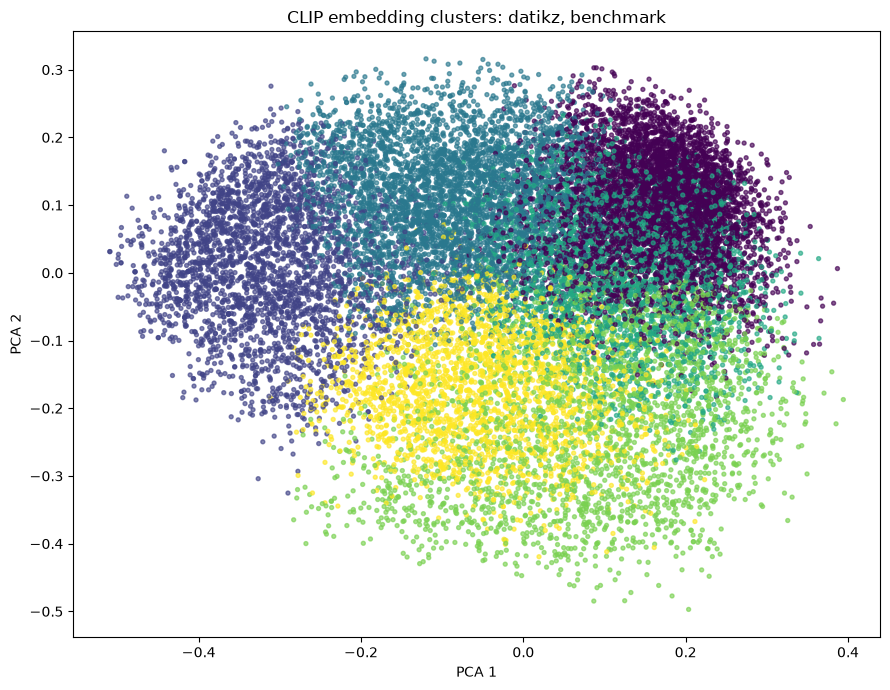

In [21]:
xy = PCA(n_components=2, random_state=SEED).fit_transform(X)

plt.figure(figsize=(9, 7))
plt.scatter(xy[:, 0], xy[:, 1], c=labels, s=8, alpha=0.65)
plt.title(f"{EMBEDDING_BACKBONE.upper()} embedding clusters: {', '.join(DATASETS_TO_USE)}")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.tight_layout()
plt.show()


### 6. Representative Examples per Cluster

The images shown are those with the smallest distance to the respective
cluster center. These are usually more meaningful than purely random examples.


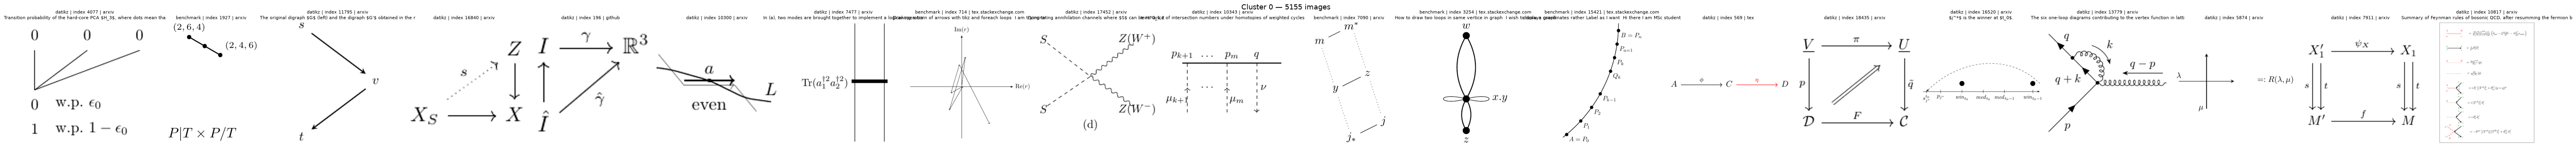

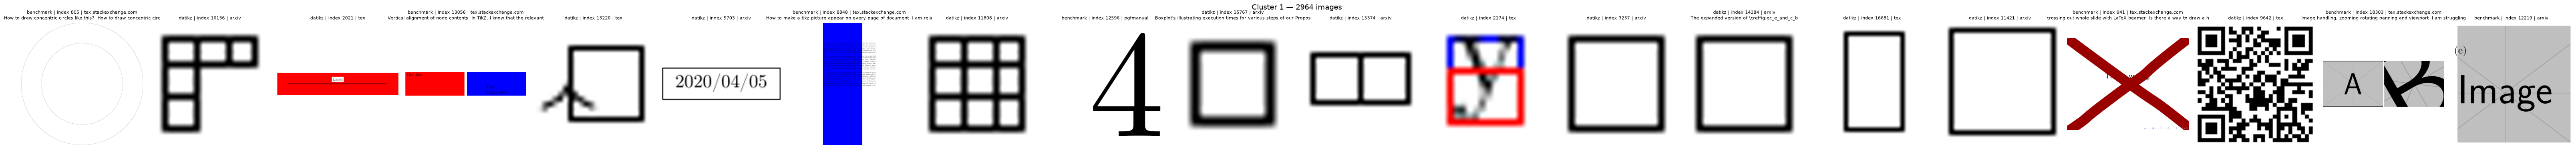

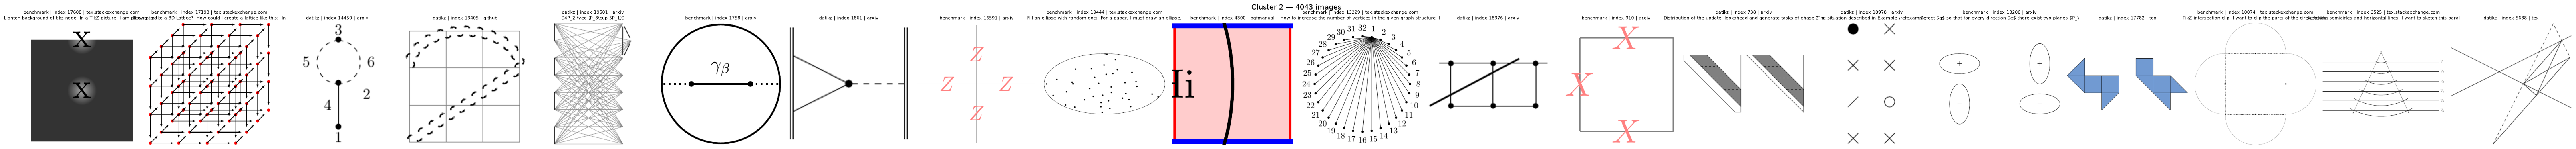

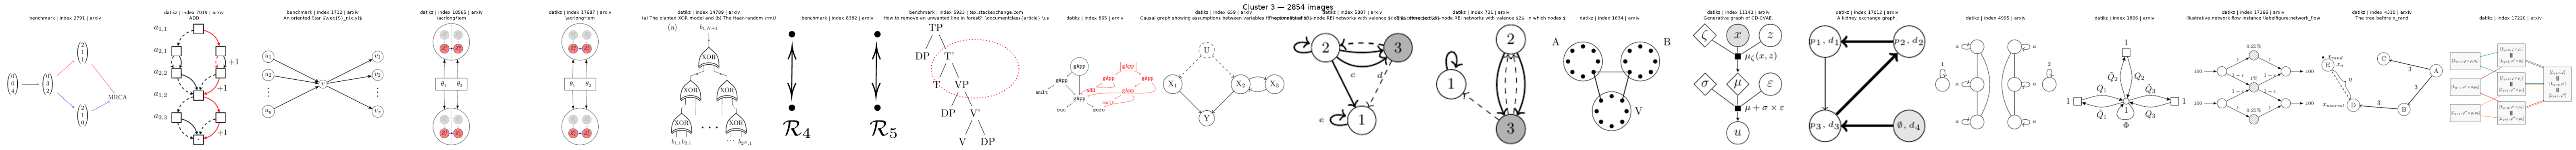

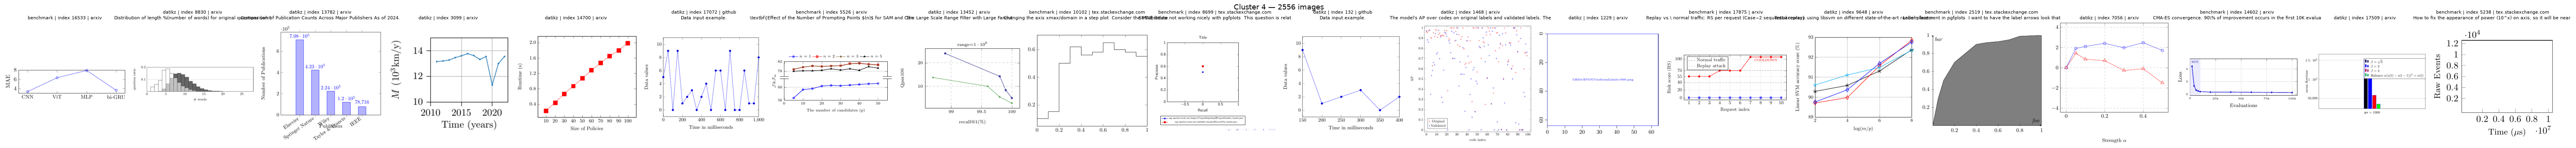

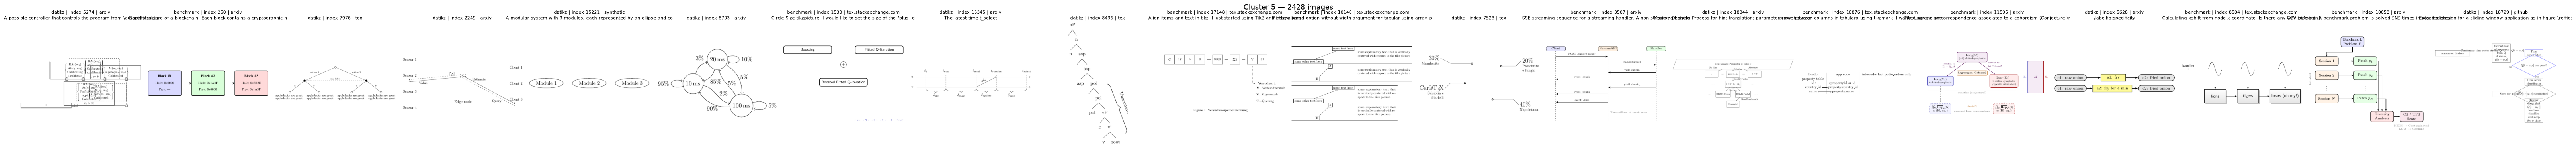

In [22]:
def show_cluster(cluster_id: int, n: int = 6):
    cluster_indices = np.where(labels == cluster_id)[0]

    if len(cluster_indices) == 0:
        print(f"Cluster {cluster_id} is empty.")
        return

    distances = np.linalg.norm(
        X[cluster_indices] - clusterer.cluster_centers_[cluster_id],
        axis=1,
    )
    selected = cluster_indices[np.argsort(distances)[:n]]

    fig, axes = plt.subplots(
        1,
        len(selected),
        figsize=(3.2 * len(selected), 3.8),
    )
    axes = np.atleast_1d(axes)

    for ax, idx in zip(axes, selected):
        row = sample[int(idx)]
        ax.imshow(row[IMAGE_COL])
        ax.axis("off")

        caption = str(row.get("caption", "") or "").replace("\n", " ")
        source = str(row.get("source", "") or "")
        dataset_name = str(row.get("dataset", ""))

        title = f"{dataset_name} | index {idx}"
        if source:
            title += f" | {source}"
        if caption:
            title += "\n" + caption[:70]

        ax.set_title(title, fontsize=8, parse_math=False)

    fig.suptitle(
        f"Cluster {cluster_id} — {len(cluster_indices)} images",
        fontsize=13,
    )
    plt.tight_layout()
    plt.show()


for cluster_id in range(N_CLUSTERS):
    show_cluster(cluster_id, n=20)


## 7. Name Clusters as Classes

After the visual review, add the names to the dictionary. The numeric
cluster IDs themselves have no semantic meaning.



In [23]:
cluster_names = {
    # Replace these examples after visual inspection:
    # 0: "Flowcharts",
    # 1: "Mathematical plots",
    # 2: "Geometric constructions",
}

results = pd.DataFrame({
    "sample_index": np.arange(len(sample)),
    "dataset": sample["dataset"],
    "sample_id": sample["sample_id"],
    "source": sample["source"],
    "cluster": labels,
})

results["class_name"] = results["cluster"].map(cluster_names)
results["class_name"] = results["class_name"].fillna(
    results["cluster"].map(lambda cluster: f"class_{cluster + 1}")
)

display(results.head())
display(
    pd.crosstab(
        results["class_name"],
        results["dataset"],
        margins=True,
    )
)

results.to_csv(
    f"{OUTPUT_PREFIX}_cluster_assignments.csv",
    index=False,
)


,sample_index,dataset,sample_id,source,cluster,class_name
0,0,benchmark,benchmark:https://tex.stackexchange.com/a/618682,tex.stackexchange.com,4,class_5
1,1,benchmark,benchmark:https://arxiv.org/abs/2511.07261,arxiv,1,class_2
2,2,benchmark,benchmark:https://arxiv.org/abs/2604.15138,arxiv,2,class_3
3,3,benchmark,benchmark:https://tex.stackexchange.com/a/492670,tex.stackexchange.com,5,class_6
4,4,benchmark,benchmark:https://tex.stackexchange.com/a/643691,tex.stackexchange.com,1,class_2


dataset,benchmark,datikz,All
class_name,,,
class_1,1987,3168,5155
class_2,1669,1295,2964
class_3,2380,1663,4043
class_4,1319,1535,2854
class_5,1255,1301,2556
class_6,1390,1038,2428
All,10000,10000,20000


### Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster and how clearly it is separated from other clusters.

For each data point:

* (a) is the average distance to all other points in the same cluster.
* (b) is the average distance to the points in the nearest neighboring cluster.

The score is calculated as:

$$
s = \frac{b-a}{\max(a,b)}
$$

The resulting value ranges from **-1 to 1**:

* **Close to 1:** compact and well-separated clusters
* **Close to 0:** clusters overlap
* **Below 0:** the point may be assigned to the wrong cluster

The overall Silhouette Score is the average score across all data points.

The score is useful for comparing different numbers of clusters. For image data, it should be combined with visual inspection to check whether the clusters also represent meaningful image categories.


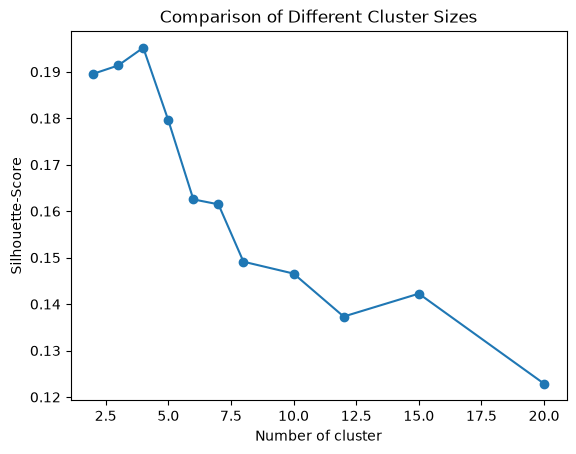

: 

In [ ]:
from sklearn.metrics import silhouette_score

scores = {}
rng = np.random.default_rng(SEED)
eval_indices = rng.choice(len(X), size=min(5_000, len(X)), replace=False)
X_eval = X[eval_indices]

for k in [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]:
    km = MiniBatchKMeans(
        n_clusters=k,
        batch_size=1024,
        n_init=10,
        random_state=SEED,
    )
    eval_labels = km.fit_predict(X_eval)
    scores[k] = silhouette_score(X_eval, eval_labels)

pd.Series(scores, name="silhouette").plot(
    marker="o",
    xlabel="Number of cluster",
    ylabel="Silhouette-Score",
    title="Comparison of Different Cluster Sizes",
)
plt.show()
